In [1]:
import numpy as np
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
LDLR_dataset = pd.read_csv('../Data/LDLR/train_node_attribute_LDLR_with_target_feature.csv')
SREBP2_dataset = pd.read_csv('../Data/SREBP2/train_node_attribute_SREBP2_with_target_feature.csv')
Influenza_dataset = pd.read_csv('../Data/Influenza/train_node_attribute_Influenza_with_target_feature.csv')
Mitomics_dataset = pd.read_csv('../Data/Mitomics/train_node_attribute_Mitomics_with_target_feature.csv')

## Feature group comparison

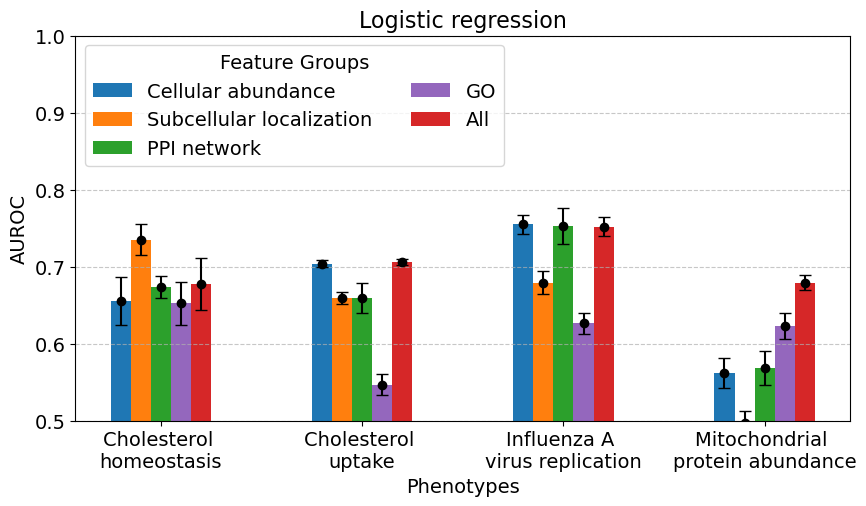

In [8]:
lr_pool_auroc = pd.DataFrame()
lr_mean_auroc = pd.DataFrame()
lr_sem_auroc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'Logistic Regression'
    data_name = model_name+'_Feature_group_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auroc = pd.read_csv(save_path+data_name+'_pool_auc_df.csv',index_col = 0)
    pheno_mean_auroc = pd.read_csv(save_path+data_name+'_mean_auc_df.csv',index_col = 0)
    pheno_sem_auroc = pd.read_csv(save_path+data_name+'_sem_auc_df.csv',index_col = 0)
    lr_pool_auroc = pd.concat([lr_pool_auroc,pheno_pool_auroc])
    lr_mean_auroc = pd.concat([lr_mean_auroc,pheno_mean_auroc])
    lr_sem_auroc = pd.concat([lr_sem_auroc,pheno_sem_auroc])
lr_pool_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
lr_mean_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
lr_sem_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auroc = lr_pool_auroc
df_mean_auroc = lr_mean_auroc
df_sem_auroc = lr_sem_auroc

# Number of categories (rows) and groups (columns)
categories = df_pool_auroc.index
df_pool_auroc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_mean_auroc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_sem_auroc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
groups = df_pool_auroc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#9467bd','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auroc.columns):
    pos = bar_positions + i * bar_width
    pool_auc = df_pool_auroc[col]
    mean_auc = df_mean_auroc[col]
    sem_auc = df_sem_auroc[col]
    plt.bar(bar_positions + i * bar_width, mean_auc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_auc,yerr = sem_auc,fmt = 'o', color = 'black',capsize = 4)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUROC',fontsize = 14)
plt.ylim((0.5,1))
plt.title('Logistic regression',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14,ncol = 2)
# plt.savefig('../Plot/Feature_importance/Feature_group_contribution_LogisticRegression.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()


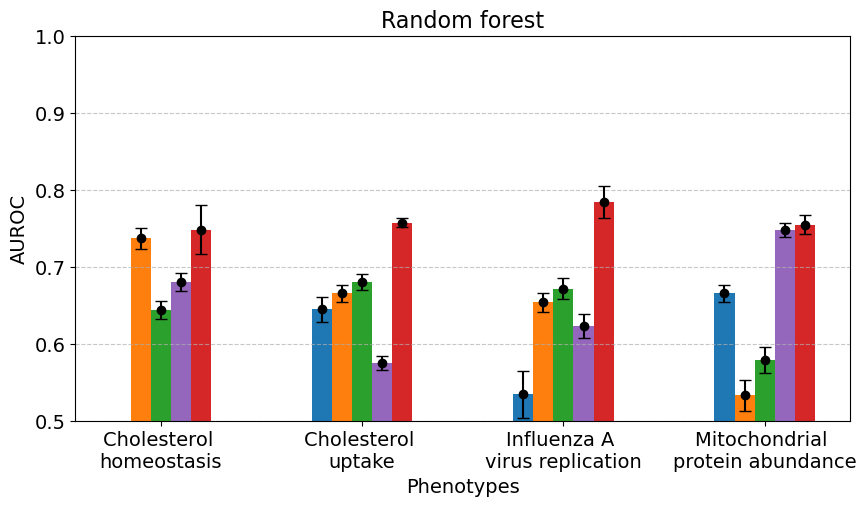

In [10]:
rf_pool_auroc = pd.DataFrame()
rf_mean_auroc = pd.DataFrame()
rf_sem_auroc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'Random Forest'
    data_name = model_name+'_Feature_group_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auroc = pd.read_csv(save_path+data_name+'_pool_auc_df.csv',index_col = 0)
    pheno_mean_auroc = pd.read_csv(save_path+data_name+'_mean_auc_df.csv',index_col = 0)
    pheno_sem_auroc = pd.read_csv(save_path+data_name+'_sem_auc_df.csv',index_col = 0)
    rf_pool_auroc = pd.concat([rf_pool_auroc,pheno_pool_auroc])
    rf_mean_auroc = pd.concat([rf_mean_auroc,pheno_mean_auroc])
    rf_sem_auroc = pd.concat([rf_sem_auroc,pheno_sem_auroc])
rf_pool_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
rf_mean_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
rf_sem_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auroc = rf_pool_auroc
df_mean_auroc = rf_mean_auroc
df_sem_auroc = rf_sem_auroc

# Number of categories (rows) and groups (columns)
categories = df_pool_auroc.index
df_pool_auroc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_mean_auroc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_sem_auroc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
groups = df_pool_auroc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))

colors = ['#1f77b4','#ff7f0e','#2ca02c','#9467bd','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auroc.columns):
    pos = bar_positions + i * bar_width
    pool_auc = df_pool_auroc[col]
    mean_auc = df_mean_auroc[col]
    sem_auc = df_sem_auroc[col]
    plt.bar(bar_positions + i * bar_width, mean_auc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_auc,yerr = sem_auc,fmt = 'o', color = 'black',capsize = 4)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUROC',fontsize = 14)
plt.ylim((0.5,1))
plt.title('Random forest',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Feature groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Feature_group_contribution_RandomForest.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()


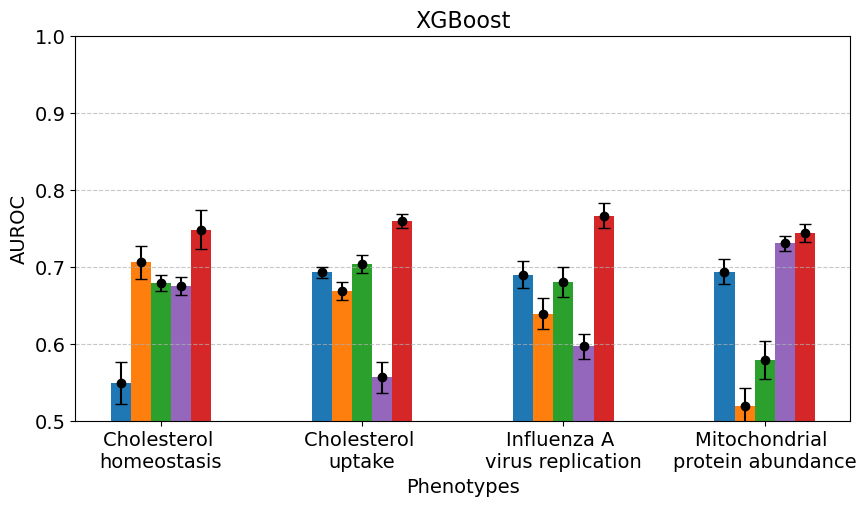

In [12]:
xgb_pool_auroc = pd.DataFrame()
xgb_mean_auroc = pd.DataFrame()
xgb_sem_auroc = pd.DataFrame()

for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'XGBoost'
    data_name = model_name+'_Feature_group_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auroc = pd.read_csv(save_path+data_name+'_pool_auc_df.csv',index_col = 0)
    pheno_mean_auroc = pd.read_csv(save_path+data_name+'_mean_auc_df.csv',index_col = 0)
    pheno_sem_auroc = pd.read_csv(save_path+data_name+'_sem_auc_df.csv',index_col = 0)
    xgb_pool_auroc = pd.concat([xgb_pool_auroc,pheno_pool_auroc])
    xgb_mean_auroc = pd.concat([xgb_mean_auroc,pheno_mean_auroc])
    xgb_sem_auroc = pd.concat([xgb_sem_auroc,pheno_sem_auroc])
xgb_pool_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
xgb_mean_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
xgb_sem_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']

# Sample DataFrame with 3 rows (categories) and 5 columns (values)
# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auroc = xgb_pool_auroc
df_mean_auroc = xgb_mean_auroc
df_sem_auroc = xgb_sem_auroc

# Number of categories (rows) and groups (columns)
categories = df_pool_auroc.index
df_pool_auroc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_mean_auroc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_sem_auroc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
groups = df_pool_auroc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))

for i, col in enumerate(df_pool_auroc.columns):
    pos = bar_positions + i * bar_width
    pool_auc = df_pool_auroc[col]
    mean_auc = df_mean_auroc[col]
    sem_auc = df_sem_auroc[col]
    plt.bar(bar_positions + i * bar_width, mean_auc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_auc,yerr = sem_auc,fmt = 'o', color = 'black',capsize = 4)

# Customize the plot
plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUROC',fontsize = 14)
plt.ylim((0.5,1))
plt.title('XGBoost',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Feature groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Feature_group_contribution_XGBoost.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()


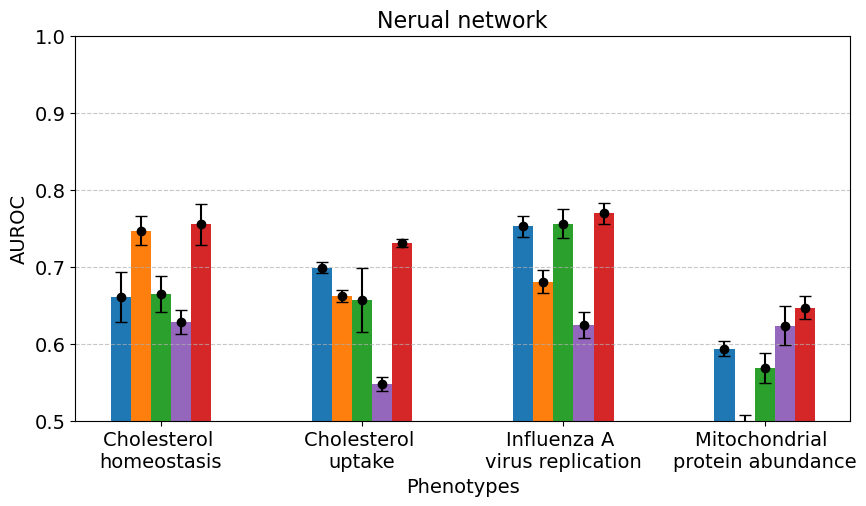

In [13]:
mlp_pool_auroc = pd.DataFrame()
mlp_mean_auroc = pd.DataFrame()
mlp_sem_auroc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'MLP'
    data_name = model_name+'_Feature_group_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auroc = pd.read_csv(save_path+data_name+'_pool_auc_df.csv',index_col = 0)
    pheno_mean_auroc = pd.read_csv(save_path+data_name+'_mean_auc_df.csv',index_col = 0)
    pheno_sem_auroc = pd.read_csv(save_path+data_name+'_sem_auc_df.csv',index_col = 0)
    mlp_pool_auroc = pd.concat([mlp_pool_auroc,pheno_pool_auroc])
    mlp_mean_auroc = pd.concat([mlp_mean_auroc,pheno_mean_auroc])
    mlp_sem_auroc = pd.concat([mlp_sem_auroc,pheno_sem_auroc])
mlp_pool_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mlp_mean_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mlp_sem_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']

# Sample DataFrame with 3 rows (categories) and 5 columns (values)
# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auroc = mlp_pool_auroc
df_mean_auroc = mlp_mean_auroc
df_sem_auroc = mlp_sem_auroc

# Number of categories (rows) and groups (columns)
categories = df_pool_auroc.index
df_pool_auroc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_mean_auroc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_sem_auroc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
groups = df_pool_auroc.columns

# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))

for i, col in enumerate(df_pool_auroc.columns):
    pos = bar_positions + i * bar_width
    pool_auc = df_pool_auroc[col]
    mean_auc = df_mean_auroc[col]
    sem_auc = df_sem_auroc[col]
    plt.bar(bar_positions + i * bar_width, mean_auc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_auc,yerr = sem_auc,fmt = 'o', color = 'black',capsize = 4)

# Customize the plot
plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUROC',fontsize = 14)
plt.ylim((0.5,1))
plt.title('Nerual network',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Feature groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Feature_group_contribution_MLP.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()


## Different part of graph feature comparison

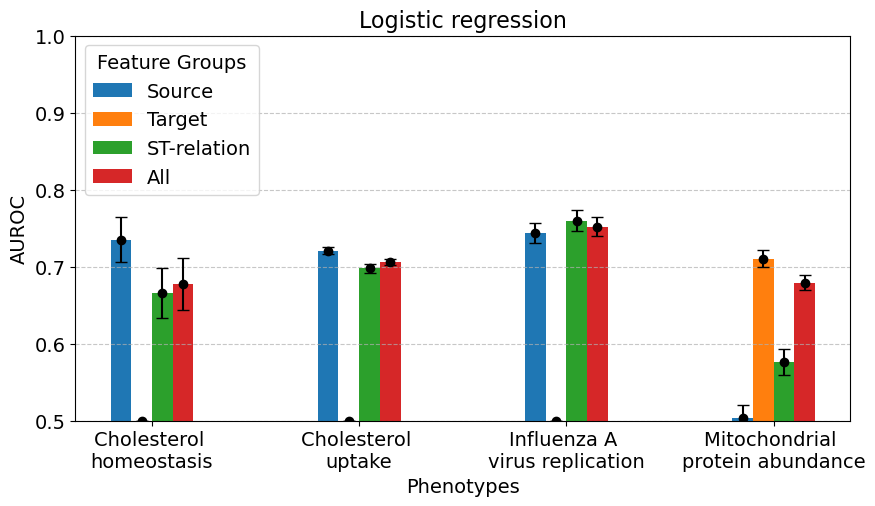

In [15]:
pool_auroc = pd.DataFrame()
mean_auroc = pd.DataFrame()
sem_auroc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'Logistic Regression'
    data_name = model_name+'_Subgraph_feature_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auroc = pd.read_csv(save_path+data_name+'_pool_auc_df.csv',index_col = 0)
    pheno_mean_auroc = pd.read_csv(save_path+data_name+'_mean_auc_df.csv',index_col = 0)
    pheno_sem_auroc = pd.read_csv(save_path+data_name+'_sem_auc_df.csv',index_col = 0)
    pool_auroc = pd.concat([pool_auroc,pheno_pool_auroc])
    mean_auroc = pd.concat([mean_auroc,pheno_mean_auroc])
    sem_auroc = pd.concat([sem_auroc,pheno_sem_auroc])
pool_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mean_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
sem_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auroc = pool_auroc
df_mean_auroc = mean_auroc
df_sem_auroc = sem_auroc

# Number of categories (rows) and groups (columns)
categories = df_pool_auroc.index
df_pool_auroc.columns = ['Source','Target','ST-relation','All']
df_mean_auroc.columns = ['Source','Target','ST-relation','All']
df_sem_auroc.columns = ['Source','Target','ST-relation','All']
groups = df_pool_auroc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auroc.columns):
    pos = bar_positions + i * bar_width
    pool_auc = df_pool_auroc[col]
    mean_auc = df_mean_auroc[col]
    sem_auc = df_sem_auroc[col]
    plt.bar(bar_positions + i * bar_width, mean_auc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_auc,yerr = sem_auc,fmt = 'o', color = 'black',capsize = 4)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUROC',fontsize = 14)
plt.ylim((0.5,1))
plt.title('Logistic regression',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Subgraph_feature_contribution_LogisticRegression.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()


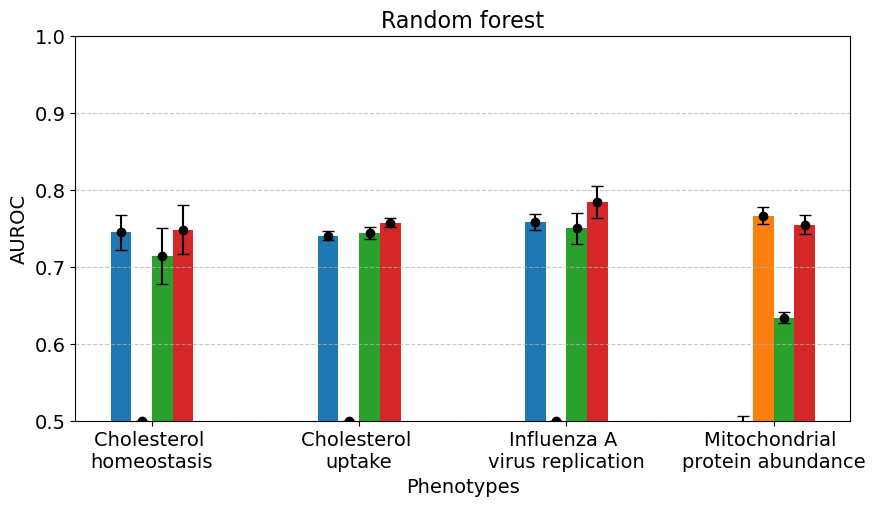

In [16]:
pool_auroc = pd.DataFrame()
mean_auroc = pd.DataFrame()
sem_auroc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'Random Forest'
    data_name = model_name+'_Subgraph_feature_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auroc = pd.read_csv(save_path+data_name+'_pool_auc_df.csv',index_col = 0)
    pheno_mean_auroc = pd.read_csv(save_path+data_name+'_mean_auc_df.csv',index_col = 0)
    pheno_sem_auroc = pd.read_csv(save_path+data_name+'_sem_auc_df.csv',index_col = 0)
    pool_auroc = pd.concat([pool_auroc,pheno_pool_auroc])
    mean_auroc = pd.concat([mean_auroc,pheno_mean_auroc])
    sem_auroc = pd.concat([sem_auroc,pheno_sem_auroc])
pool_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mean_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
sem_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auroc = pool_auroc
df_mean_auroc = mean_auroc
df_sem_auroc = sem_auroc

# Number of categories (rows) and groups (columns)
categories = df_pool_auroc.index
df_pool_auroc.columns = ['Source','Target','ST-relation','All']
df_mean_auroc.columns = ['Source','Target','ST-relation','All']
df_sem_auroc.columns = ['Source','Target','ST-relation','All']
groups = df_pool_auroc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auroc.columns):
    pos = bar_positions + i * bar_width
    pool_auc = df_pool_auroc[col]
    mean_auc = df_mean_auroc[col]
    sem_auc = df_sem_auroc[col]
    plt.bar(bar_positions + i * bar_width, mean_auc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_auc,yerr = sem_auc,fmt = 'o', color = 'black',capsize = 4)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUROC',fontsize = 14)
plt.ylim((0.5,1))
plt.title('Random forest',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Subgraph_feature_contribution_RandomForeset.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()


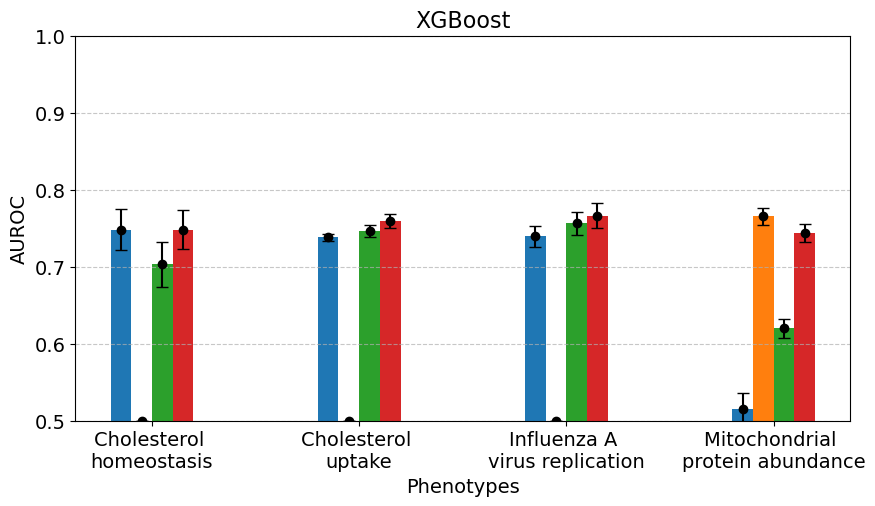

In [17]:
pool_auroc = pd.DataFrame()
mean_auroc = pd.DataFrame()
sem_auroc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'XGBoost'
    data_name = model_name+'_Subgraph_feature_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auroc = pd.read_csv(save_path+data_name+'_pool_auc_df.csv',index_col = 0)
    pheno_mean_auroc = pd.read_csv(save_path+data_name+'_mean_auc_df.csv',index_col = 0)
    pheno_sem_auroc = pd.read_csv(save_path+data_name+'_sem_auc_df.csv',index_col = 0)
    pool_auroc = pd.concat([pool_auroc,pheno_pool_auroc])
    mean_auroc = pd.concat([mean_auroc,pheno_mean_auroc])
    sem_auroc = pd.concat([sem_auroc,pheno_sem_auroc])
pool_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mean_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
sem_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auroc = pool_auroc
df_mean_auroc = mean_auroc
df_sem_auroc = sem_auroc

# Number of categories (rows) and groups (columns)
categories = df_pool_auroc.index
df_pool_auroc.columns = ['Source','Target','ST-relation','All']
df_mean_auroc.columns = ['Source','Target','ST-relation','All']
df_sem_auroc.columns = ['Source','Target','ST-relation','All']
groups = df_pool_auroc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auroc.columns):
    pos = bar_positions + i * bar_width
    pool_auc = df_pool_auroc[col]
    mean_auc = df_mean_auroc[col]
    sem_auc = df_sem_auroc[col]
    plt.bar(bar_positions + i * bar_width, mean_auc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_auc,yerr = sem_auc,fmt = 'o', color = 'black',capsize = 4)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUROC',fontsize = 14)
plt.ylim((0.5,1))
plt.title('XGBoost',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Subgraph_part_feature_contribution_XGBoost.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()


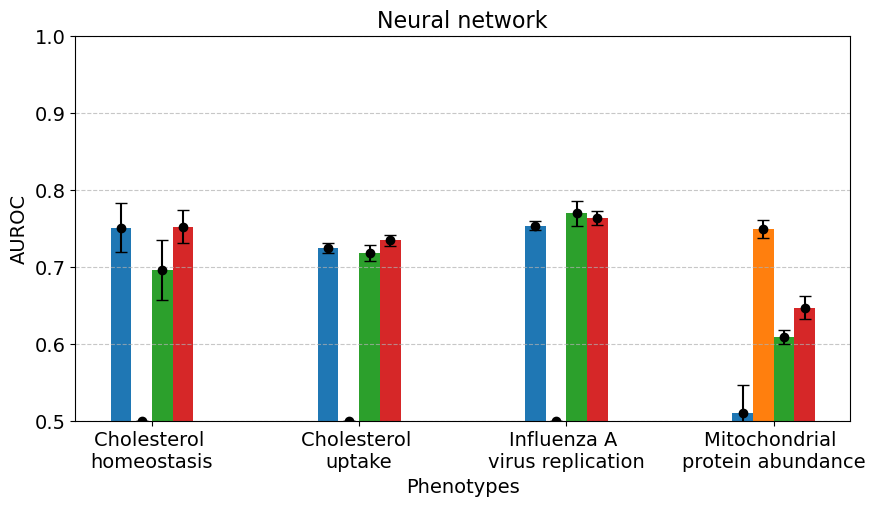

In [18]:
pool_auroc = pd.DataFrame()
mean_auroc = pd.DataFrame()
sem_auroc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'MLP'
    data_name = model_name+'_Subgraph_feature_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auroc = pd.read_csv(save_path+data_name+'_pool_auc_df.csv',index_col = 0)
    pheno_mean_auroc = pd.read_csv(save_path+data_name+'_mean_auc_df.csv',index_col = 0)
    pheno_sem_auroc = pd.read_csv(save_path+data_name+'_sem_auc_df.csv',index_col = 0)
    pool_auroc = pd.concat([pool_auroc,pheno_pool_auroc])
    mean_auroc = pd.concat([mean_auroc,pheno_mean_auroc])
    sem_auroc = pd.concat([sem_auroc,pheno_sem_auroc])
pool_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mean_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
sem_auroc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auroc = pool_auroc
df_mean_auroc = mean_auroc
df_sem_auroc = sem_auroc

# Number of categories (rows) and groups (columns)
categories = df_pool_auroc.index
df_pool_auroc.columns = ['Source','Target','ST-relation','All']
df_mean_auroc.columns = ['Source','Target','ST-relation','All']
df_sem_auroc.columns = ['Source','Target','ST-relation','All']
groups = df_pool_auroc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auroc.columns):
    pos = bar_positions + i * bar_width
    pool_auc = df_pool_auroc[col]
    mean_auc = df_mean_auroc[col]
    sem_auc = df_sem_auroc[col]
    plt.bar(bar_positions + i * bar_width, mean_auc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_auc,yerr = sem_auc,fmt = 'o', color = 'black',capsize = 4)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUROC',fontsize = 14)
plt.ylim((0.5,1))
plt.title('Neural network',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Subgraph_feature_contribution_MLP.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()


### Precision-Recalls

In [19]:
LDLR_baseline = LDLR_dataset['label'].sum()/len(LDLR_dataset)
SREBP2_baseline = SREBP2_dataset['label'].sum()/len(SREBP2_dataset)
Influenza_baseline = Influenza_dataset['label'].sum()/len(Influenza_dataset)
Mitomics_baseline = Mitomics_dataset['label'].sum()/len(Mitomics_dataset)

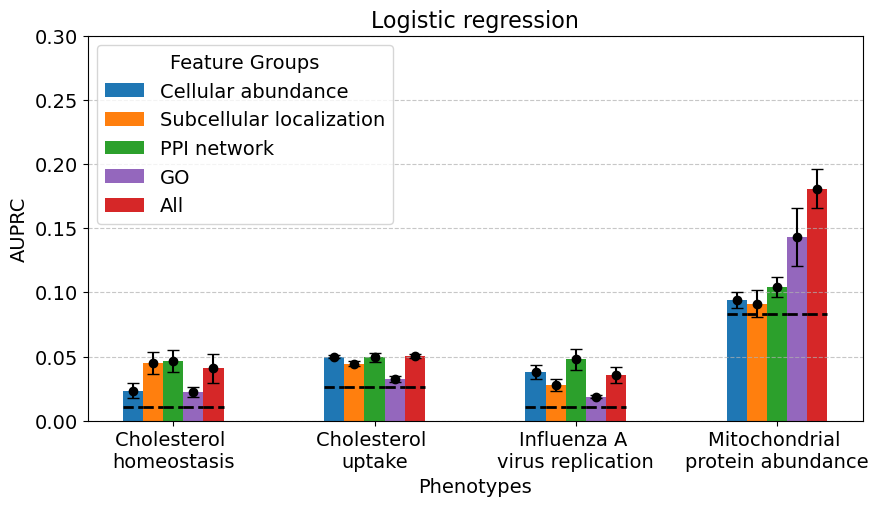

In [20]:
pool_auprc = pd.DataFrame()
mean_auprc = pd.DataFrame()
sem_auprc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'Logistic Regression'
    data_name = model_name+'_Feature_group_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auprc = pd.read_csv(save_path+data_name+'_pool_prc_df.csv',index_col = 0)
    pheno_mean_auprc = pd.read_csv(save_path+data_name+'_mean_prc_df.csv',index_col = 0)
    pheno_sem_auprc = pd.read_csv(save_path+data_name+'_sem_prc_df.csv',index_col = 0)
    pool_auprc = pd.concat([pool_auprc,pheno_pool_auprc])
    mean_auprc = pd.concat([mean_auprc,pheno_mean_auprc])
    sem_auprc = pd.concat([sem_auprc,pheno_sem_auprc])
pool_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mean_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
sem_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auprc = pool_auprc
df_mean_auprc = mean_auprc
df_sem_auprc = sem_auprc

# Number of categories (rows) and groups (columns)
categories = df_pool_auprc.index
df_pool_auprc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_mean_auprc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_sem_auprc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
groups = df_pool_auprc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#9467bd','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auprc.columns):
    pos = bar_positions + i * bar_width
    pool_auc = df_pool_auprc[col]
    mean_auc = df_mean_auprc[col]
    sem_auc = df_sem_auprc[col]
    baseline = [SREBP2_baseline,LDLR_baseline,Influenza_baseline,Mitomics_baseline]
    plt.bar(bar_positions + i * bar_width, mean_auc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_auc,yerr = sem_auc,fmt = 'o', color = 'black',capsize = 4)
    for j in range(len(mean_auc)):
        x_center = pos[j]
        x_left = x_center - bar_width / 2
        x_right = x_center + bar_width / 2
        plt.hlines(y=baseline[j], xmin=x_left, xmax=x_right,linestyles='dashed', colors='black', linewidth=2)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUPRC',fontsize = 14)
plt.ylim((0,0.3))
plt.title('Logistic regression',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Feature_group_contribution_LogisticRegression_PRC.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()


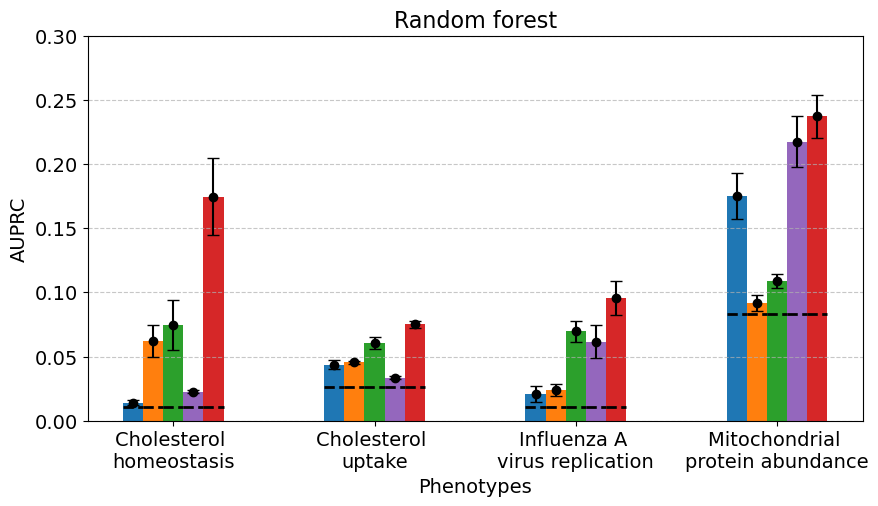

In [22]:
pool_auprc = pd.DataFrame()
mean_auprc = pd.DataFrame()
sem_auprc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'Random Forest'
    data_name = model_name+'_Feature_group_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auprc = pd.read_csv(save_path+data_name+'_pool_prc_df.csv',index_col = 0)
    pheno_mean_auprc = pd.read_csv(save_path+data_name+'_mean_prc_df.csv',index_col = 0)
    pheno_sem_auprc = pd.read_csv(save_path+data_name+'_sem_prc_df.csv',index_col = 0)
    pool_auprc = pd.concat([pool_auprc,pheno_pool_auprc])
    mean_auprc = pd.concat([mean_auprc,pheno_mean_auprc])
    sem_auprc = pd.concat([sem_auprc,pheno_sem_auprc])
pool_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mean_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
sem_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auprc = pool_auprc
df_mean_auprc = mean_auprc
df_sem_auprc = sem_auprc

# Number of categories (rows) and groups (columns)
categories = df_pool_auprc.index
df_pool_auprc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_mean_auprc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_sem_auprc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
groups = df_pool_auprc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#9467bd','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auprc.columns):
    pos = bar_positions + i * bar_width
    pool_prc = df_pool_auprc[col]
    mean_prc = df_mean_auprc[col]
    sem_prc = df_sem_auprc[col]
    baseline = [SREBP2_baseline,LDLR_baseline,Influenza_baseline,Mitomics_baseline]
    plt.bar(bar_positions + i * bar_width, mean_prc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_prc,yerr = sem_prc,fmt = 'o', color = 'black',capsize = 4)
    for j in range(len(mean_auc)):
        x_center = pos[j]
        x_left = x_center - bar_width / 2
        x_right = x_center + bar_width / 2
        plt.hlines(y=baseline[j], xmin=x_left, xmax=x_right,linestyles='dashed', colors='black', linewidth=2)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUPRC',fontsize = 14)
plt.ylim((0,0.3))
plt.title('Random forest',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Feature_group_contribution_RandomForeest_AUPRC.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()


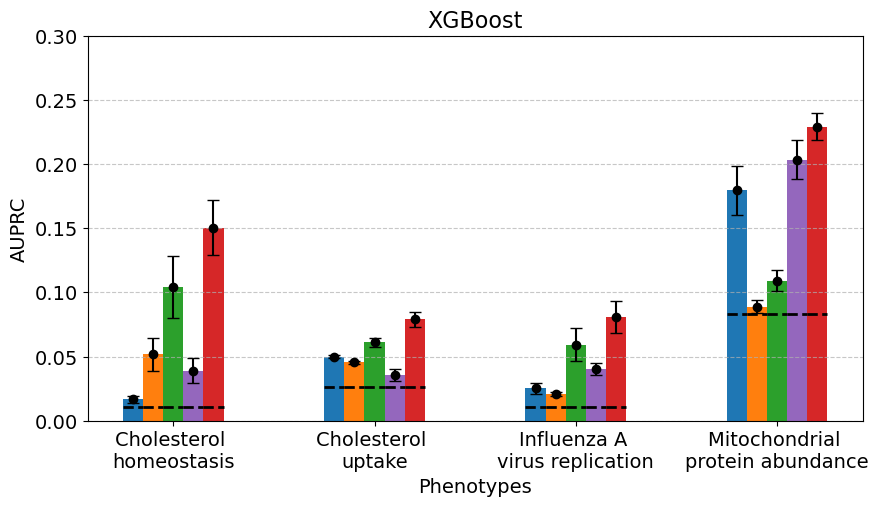

In [23]:
pool_auprc = pd.DataFrame()
mean_auprc = pd.DataFrame()
sem_auprc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'XGBoost'
    data_name = model_name+'_Feature_group_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auprc = pd.read_csv(save_path+data_name+'_pool_prc_df.csv',index_col = 0)
    pheno_mean_auprc = pd.read_csv(save_path+data_name+'_mean_prc_df.csv',index_col = 0)
    pheno_sem_auprc = pd.read_csv(save_path+data_name+'_sem_prc_df.csv',index_col = 0)
    pool_auprc = pd.concat([pool_auprc,pheno_pool_auprc])
    mean_auprc = pd.concat([mean_auprc,pheno_mean_auprc])
    sem_auprc = pd.concat([sem_auprc,pheno_sem_auprc])
pool_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mean_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
sem_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auprc = pool_auprc
df_mean_auprc = mean_auprc
df_sem_auprc = sem_auprc

# Number of categories (rows) and groups (columns)
categories = df_pool_auprc.index
df_pool_auprc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_mean_auprc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_sem_auprc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
groups = df_pool_auprc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#9467bd','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auprc.columns):
    pos = bar_positions + i * bar_width
    pool_prc = df_pool_auprc[col]
    mean_prc = df_mean_auprc[col]
    sem_prc = df_sem_auprc[col]
    baseline = [SREBP2_baseline,LDLR_baseline,Influenza_baseline,Mitomics_baseline]
    plt.bar(bar_positions + i * bar_width, mean_prc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_prc,yerr = sem_prc,fmt = 'o', color = 'black',capsize = 4)
    for j in range(len(mean_auc)):
        x_center = pos[j]
        x_left = x_center - bar_width / 2
        x_right = x_center + bar_width / 2
        plt.hlines(y=baseline[j], xmin=x_left, xmax=x_right,linestyles='dashed', colors='black', linewidth=2)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUPRC',fontsize = 14)
plt.ylim((0,0.3))
plt.title('XGBoost',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Feature_group_contribution_XGBoost_AUPRC.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()


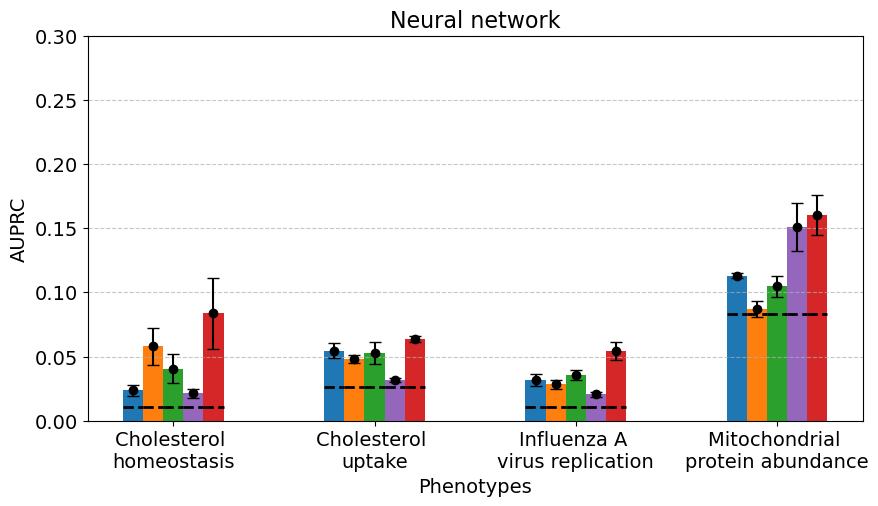

In [24]:
pool_auprc = pd.DataFrame()
mean_auprc = pd.DataFrame()
sem_auprc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'MLP'
    data_name = model_name+'_Feature_group_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auprc = pd.read_csv(save_path+data_name+'_pool_prc_df.csv',index_col = 0)
    pheno_mean_auprc = pd.read_csv(save_path+data_name+'_mean_prc_df.csv',index_col = 0)
    pheno_sem_auprc = pd.read_csv(save_path+data_name+'_sem_prc_df.csv',index_col = 0)
    pool_auprc = pd.concat([pool_auprc,pheno_pool_auprc])
    mean_auprc = pd.concat([mean_auprc,pheno_mean_auprc])
    sem_auprc = pd.concat([sem_auprc,pheno_sem_auprc])
pool_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mean_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
sem_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auprc = pool_auprc
df_mean_auprc = mean_auprc
df_sem_auprc = sem_auprc

# Number of categories (rows) and groups (columns)
categories = df_pool_auprc.index
df_pool_auprc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_mean_auprc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
df_sem_auprc.columns = ['Cellular abundance','Subcellular localization','PPI network','GO','All']
groups = df_pool_auprc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#9467bd','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auprc.columns):
    pos = bar_positions + i * bar_width
    pool_prc = df_pool_auprc[col]
    mean_prc = df_mean_auprc[col]
    sem_prc = df_sem_auprc[col]
    baseline = [SREBP2_baseline,LDLR_baseline,Influenza_baseline,Mitomics_baseline]
    plt.bar(bar_positions + i * bar_width, mean_prc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_prc,yerr = sem_prc,fmt = 'o', color = 'black',capsize = 4)
    for j in range(len(mean_auc)):
        x_center = pos[j]
        x_left = x_center - bar_width / 2
        x_right = x_center + bar_width / 2
        plt.hlines(y=baseline[j], xmin=x_left, xmax=x_right,linestyles='dashed', colors='black', linewidth=2)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUPRC',fontsize = 14)
plt.ylim((0,0.3))
plt.title('Neural network',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Feature_group_contribution_MLP_AUPRC.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()


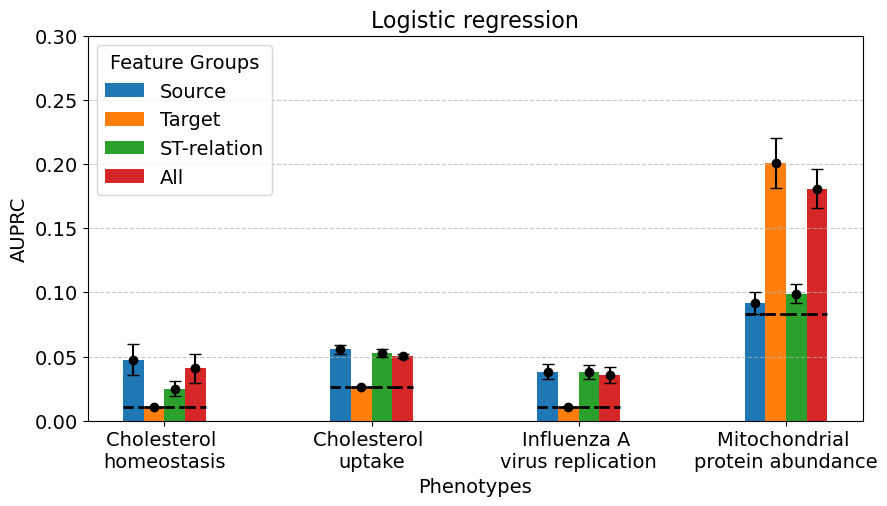

In [26]:
pool_auprc = pd.DataFrame()
mean_auprc = pd.DataFrame()
sem_auprc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'Logistic Regression'
    data_name = model_name+'_Subgraph_feature_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auprc = pd.read_csv(save_path+data_name+'_pool_prc_df.csv',index_col = 0)
    pheno_mean_auprc = pd.read_csv(save_path+data_name+'_mean_prc_df.csv',index_col = 0)
    pheno_sem_auprc = pd.read_csv(save_path+data_name+'_sem_prc_df.csv',index_col = 0)
    pool_auprc = pd.concat([pool_auprc,pheno_pool_auprc])
    mean_auprc = pd.concat([mean_auprc,pheno_mean_auprc])
    sem_auprc = pd.concat([sem_auprc,pheno_sem_auprc])
pool_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mean_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
sem_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auprc = pool_auprc
df_mean_auprc = mean_auprc
df_sem_auprc = sem_auprc


# Number of categories (rows) and groups (columns)
categories = df_pool_auprc.index
df_pool_auprc.columns = ['Source','Target','ST-relation','All']
df_mean_auprc.columns = ['Source','Target','ST-relation','All']
df_sem_auprc.columns = ['Source','Target','ST-relation','All']
groups = df_pool_auprc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auprc.columns):
    pos = bar_positions + i * bar_width
    pool_prc = df_pool_auprc[col]
    mean_prc = df_mean_auprc[col]
    sem_prc = df_sem_auprc[col]
    baseline = [SREBP2_baseline,LDLR_baseline,Influenza_baseline,Mitomics_baseline]
    plt.bar(bar_positions + i * bar_width, mean_prc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_prc,yerr = sem_prc,fmt = 'o', color = 'black',capsize = 4)
    for j in range(len(mean_auc)):
        x_center = pos[j]
        x_left = x_center - bar_width / 2
        x_right = x_center + bar_width / 2
        plt.hlines(y=baseline[j], xmin=x_left, xmax=x_right,linestyles='dashed', colors='black', linewidth=2)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUPRC',fontsize = 14)
plt.ylim((0,0.3))
plt.title('Logistic regression',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Subgraph_feature_contribution_LogisticRegression_AUPRC.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()

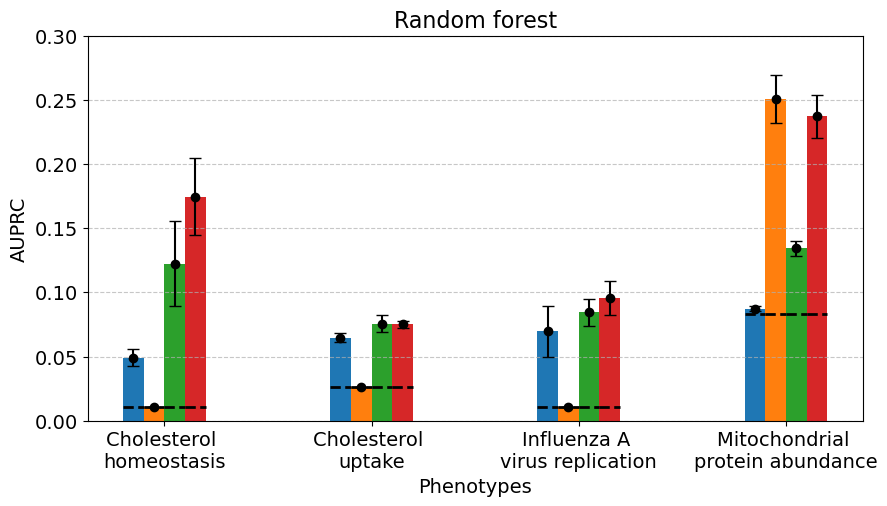

In [28]:
pool_auprc = pd.DataFrame()
mean_auprc = pd.DataFrame()
sem_auprc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'Random Forest'
    data_name = model_name+'_Subgraph_feature_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auprc = pd.read_csv(save_path+data_name+'_pool_prc_df.csv',index_col = 0)
    pheno_mean_auprc = pd.read_csv(save_path+data_name+'_mean_prc_df.csv',index_col = 0)
    pheno_sem_auprc = pd.read_csv(save_path+data_name+'_sem_prc_df.csv',index_col = 0)
    pool_auprc = pd.concat([pool_auprc,pheno_pool_auprc])
    mean_auprc = pd.concat([mean_auprc,pheno_mean_auprc])
    sem_auprc = pd.concat([sem_auprc,pheno_sem_auprc])
pool_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mean_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
sem_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auprc = pool_auprc
df_mean_auprc = mean_auprc
df_sem_auprc = sem_auprc


# Number of categories (rows) and groups (columns)
categories = df_pool_auprc.index
df_pool_auprc.columns = ['Source','Target','ST-relation','All']
df_mean_auprc.columns = ['Source','Target','ST-relation','All']
df_sem_auprc.columns = ['Source','Target','ST-relation','All']
groups = df_pool_auprc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auprc.columns):
    pos = bar_positions + i * bar_width
    pool_prc = df_pool_auprc[col]
    mean_prc = df_mean_auprc[col]
    sem_prc = df_sem_auprc[col]
    baseline = [SREBP2_baseline,LDLR_baseline,Influenza_baseline,Mitomics_baseline]
    plt.bar(bar_positions + i * bar_width, mean_prc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_prc,yerr = sem_prc,fmt = 'o', color = 'black',capsize = 4)
    for j in range(len(mean_auc)):
        x_center = pos[j]
        x_left = x_center - bar_width / 2
        x_right = x_center + bar_width / 2
        plt.hlines(y=baseline[j], xmin=x_left, xmax=x_right,linestyles='dashed', colors='black', linewidth=2)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUPRC',fontsize = 14)
plt.ylim((0,0.3))
plt.title('Random forest',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Subgraph_feature_contribution_RandomForest_AUPRC.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()

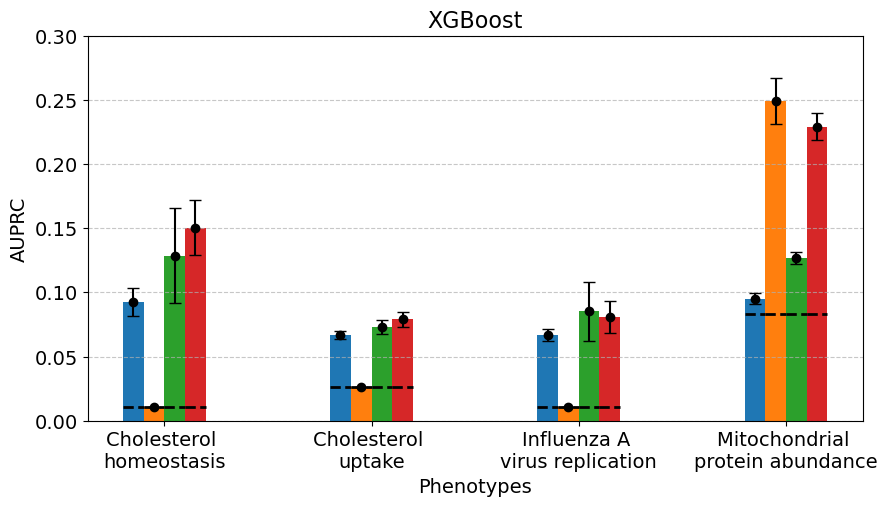

In [29]:
pool_auprc = pd.DataFrame()
mean_auprc = pd.DataFrame()
sem_auprc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'XGBoost'
    data_name = model_name+'_Subgraph_feature_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auprc = pd.read_csv(save_path+data_name+'_pool_prc_df.csv',index_col = 0)
    pheno_mean_auprc = pd.read_csv(save_path+data_name+'_mean_prc_df.csv',index_col = 0)
    pheno_sem_auprc = pd.read_csv(save_path+data_name+'_sem_prc_df.csv',index_col = 0)
    pool_auprc = pd.concat([pool_auprc,pheno_pool_auprc])
    mean_auprc = pd.concat([mean_auprc,pheno_mean_auprc])
    sem_auprc = pd.concat([sem_auprc,pheno_sem_auprc])
pool_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mean_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
sem_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auprc = pool_auprc
df_mean_auprc = mean_auprc
df_sem_auprc = sem_auprc


# Number of categories (rows) and groups (columns)
categories = df_pool_auprc.index
df_pool_auprc.columns = ['Source','Target','ST-relation','All']
df_mean_auprc.columns = ['Source','Target','ST-relation','All']
df_sem_auprc.columns = ['Source','Target','ST-relation','All']
groups = df_pool_auprc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auprc.columns):
    pos = bar_positions + i * bar_width
    pool_prc = df_pool_auprc[col]
    mean_prc = df_mean_auprc[col]
    sem_prc = df_sem_auprc[col]
    baseline = [SREBP2_baseline,LDLR_baseline,Influenza_baseline,Mitomics_baseline]
    plt.bar(bar_positions + i * bar_width, mean_prc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_prc,yerr = sem_prc,fmt = 'o', color = 'black',capsize = 4)
    for j in range(len(mean_auc)):
        x_center = pos[j]
        x_left = x_center - bar_width / 2
        x_right = x_center + bar_width / 2
        plt.hlines(y=baseline[j], xmin=x_left, xmax=x_right,linestyles='dashed', colors='black', linewidth=2)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUPRC',fontsize = 14)
plt.ylim((0,0.3))
plt.title('XGBoost',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Subgraph_feature_contribution_XGBoost_AUPRC.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()

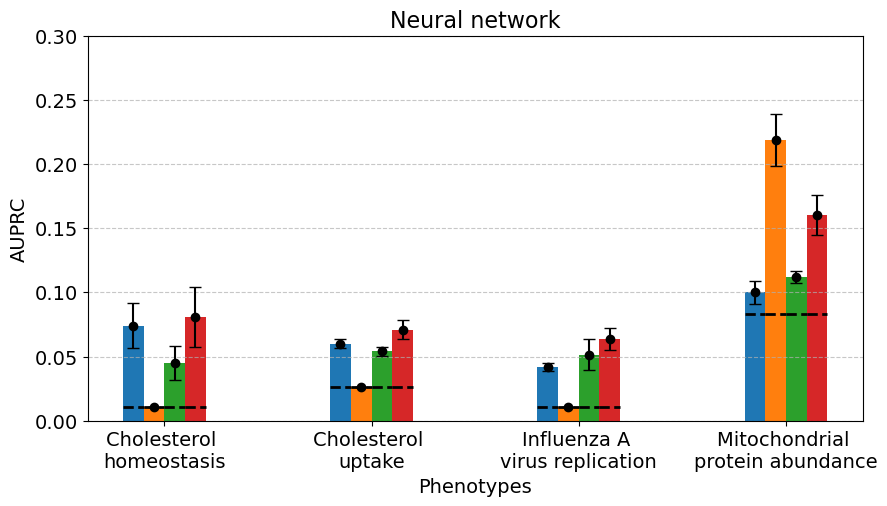

In [30]:
pool_auprc = pd.DataFrame()
mean_auprc = pd.DataFrame()
sem_auprc = pd.DataFrame()
for phenotype in ['SREBP2','LDLR','Influenza','Mitomics']:
    model_name = 'MLP'
    data_name = model_name+'_Subgraph_feature_comparison_'+phenotype
    save_path = '../Plot/'+phenotype+'/'
    pheno_pool_auprc = pd.read_csv(save_path+data_name+'_pool_prc_df.csv',index_col = 0)
    pheno_mean_auprc = pd.read_csv(save_path+data_name+'_mean_prc_df.csv',index_col = 0)
    pheno_sem_auprc = pd.read_csv(save_path+data_name+'_sem_prc_df.csv',index_col = 0)
    pool_auprc = pd.concat([pool_auprc,pheno_pool_auprc])
    mean_auprc = pd.concat([mean_auprc,pheno_mean_auprc])
    sem_auprc = pd.concat([sem_auprc,pheno_sem_auprc])
pool_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
mean_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']
sem_auprc.index = ['Cholesterol \nhomeostasis','Cholesterol \nuptake','Influenza A \nvirus replication','Mitochondrial \nprotein abundance']


# Sample DataFrame with 3 rows (categories) and 5 columns (values)
df_pool_auprc = pool_auprc
df_mean_auprc = mean_auprc
df_sem_auprc = sem_auprc


# Number of categories (rows) and groups (columns)
categories = df_pool_auprc.index
df_pool_auprc.columns = ['Source','Target','ST-relation','All']
df_mean_auprc.columns = ['Source','Target','ST-relation','All']
df_sem_auprc.columns = ['Source','Target','ST-relation','All']
groups = df_pool_auprc.columns


# Bar width and positions for bars
bar_width = 0.1
bar_positions = np.arange(len(categories))

# Create a figure
plt.figure(figsize=(10, 5))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
# Plot bars for each group (column)
for i, col in enumerate(df_pool_auprc.columns):
    pos = bar_positions + i * bar_width
    pool_prc = df_pool_auprc[col]
    mean_prc = df_mean_auprc[col]
    sem_prc = df_sem_auprc[col]
    baseline = [SREBP2_baseline,LDLR_baseline,Influenza_baseline,Mitomics_baseline]
    plt.bar(bar_positions + i * bar_width, mean_prc, width=bar_width, label=col,color = colors[i])
    plt.errorbar(pos,mean_prc,yerr = sem_prc,fmt = 'o', color = 'black',capsize = 4)
    for j in range(len(mean_auc)):
        x_center = pos[j]
        x_left = x_center - bar_width / 2
        x_right = x_center + bar_width / 2
        plt.hlines(y=baseline[j], xmin=x_left, xmax=x_right,linestyles='dashed', colors='black', linewidth=2)

plt.xlabel('Phenotypes',fontsize = 14)
plt.ylabel('AUPRC',fontsize = 14)
plt.ylim((0,0.3))
plt.title('Neural network',fontsize = 16)
plt.xticks(bar_positions + bar_width * (len(groups) - 1) / 2, [f'{i}' for i in categories],fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Feature Groups',loc = 'upper left',fontsize = 14,title_fontsize = 14)
# plt.savefig('../Plot/Feature_importance/Subgraph_feature_contribution_MLP_AUPRC.png',dpi = 800,bbox_inches='tight')
# Show the plot
plt.show()